# Classification - Sınıflandırma

In [1]:
import pandas as pd  # Veri analizi ve tablo işlemleri için pandas kütüphanesi

pd.set_option('display.max_columns', 100)  # DataFrame yazdırırken en fazla 100 sütun göster

import warnings  # Python uyarı (warning) mesajlarını yönetmek için kullanılır
warnings.filterwarnings('ignore')  # Uyarı mesajlarını ekranda göstermeyi kapat

import matplotlib.pyplot as plt  # Grafik çizmek için temel görselleştirme kütüphanesi
import seaborn as sns  # Daha estetik ve gelişmiş veri görselleştirme kütüphanesi

In [2]:
df=pd.read_csv('hr_data.csv') 

## EDA - Exploratory Data Analysis

In [3]:
df.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,2,5993.0,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5,Yes
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,1,5130.0,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7,No
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,2,2090.0,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0,Yes
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,1,2909.0,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0,No
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,1,3468.0,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2,No


In [4]:
df.shape

(1470, 35)

In [5]:
df.isnull().sum()

Age                           0
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EmployeeNumber                0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBalance               0
YearsAtCompany                0
YearsInC

In [6]:
# Attrition - İşten Ayrılma - İş gücü kaybı

<Axes: xlabel='Attrition', ylabel='count'>

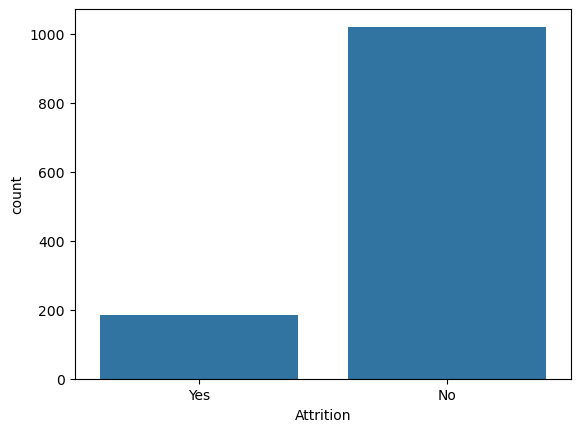

In [7]:
sns.countplot(x=df['Attrition'])

In [8]:
# Imbalanced Data (Imbalanced Data (Dengesiz Veri), sınıflandırma problemlerinde sınıf dağılımının eşit olmaması durumudur.)
# Imbalanceed data SMOTE (az olan sınıfı “gerçek veri üretmeden” yapay verilerle artırır.)

In [9]:
empty = df[df['Attrition'].isnull()]  
# Attrition sütunu boş (NaN) olan satırları seçer → eksik hedef/etiket veriler

full = df[df['Attrition'].notnull()]  
# Attrition sütunu dolu olan satırları seçer → kullanılabilir (tam) veriler

In [10]:
full.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,2,5993.0,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5,Yes
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,1,5130.0,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7,No
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,2,2090.0,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0,Yes
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,1,2909.0,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0,No
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,1,3468.0,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2,No


In [11]:
d = { 'Yes' : 1 , 'No' : 0}

In [12]:
full['Attrition'] = full['Attrition'].map(d)

In [13]:
x = full.drop('Attrition', axis=1)  
# Attrition sütununu (hedef değişkeni) çıkarır, geriye sadece feature'lar kalır

y = full[['Attrition']]  
# Attrition sütununu hedef değişken (y) olarak seçer

In [14]:
x = pd.get_dummies(x, drop_first=True)  
# Kategorik (yazı) sütunları sayısal sütunlara çevirir (One-Hot Encoding yapar)
# drop_first=True → gereksiz tekrar eden sütunu siler (multicollinearity önlemek için)

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.15,random_state=42)

In [17]:
# Naive Bayes : İhtimaller hesabına göre tahmin eden model

In [18]:
from sklearn.naive_bayes import GaussianNB  
# Sürekli (sayısal) veriler için kullanılan Naive Bayes modeli

from sklearn.naive_bayes import BernoulliNB  
# İkili (0/1, True/False) veriler için kullanılan Naive Bayes modeli

In [32]:
g = GaussianNB()	# Gaussian Naive Bayes modelini oluşturur (sürekli/sayısal veriler için)

b = BernoulliNB()   # Bernoulli Naive Bayes modelini oluşturur (0/1 yani binary veriler için)

In [29]:
modelb = b.fit(x_train, y_train) # Bernoulli model eğitimi
modelg = g.fit(x_train, y_train) # Gaussian model eğitimi

In [31]:
gtahmin = g.predict(x_test) # Gaussian Naive Bayes modelinin, test verisi (x_test) için tahmin üretmesini sağlar

In [30]:
btahmin = b.predict(x_test) # Bernoulli Naive Bayes modelinin test verisi (x_test) için sınıf tahmini yapmasını sağlar

In [35]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [36]:
accuracy_score(y_test, btahmin)

0.850828729281768

In [37]:
confusion_matrix(y_test, btahmin)

array([[149,  13],
       [ 14,   5]])

In [40]:
accuracy_score(y_test, gtahmin)

0.7955801104972375

In [39]:
confusion_matrix(y_test, gtahmin)

array([[132,  30],
       [  7,  12]])

In [41]:
print(classification_report(y_test, gtahmin))

              precision    recall  f1-score   support

           0       0.95      0.81      0.88       162
           1       0.29      0.63      0.39        19

    accuracy                           0.80       181
   macro avg       0.62      0.72      0.64       181
weighted avg       0.88      0.80      0.83       181



In [42]:
print(classification_report(y_test, btahmin))

              precision    recall  f1-score   support

           0       0.91      0.92      0.92       162
           1       0.28      0.26      0.27        19

    accuracy                           0.85       181
   macro avg       0.60      0.59      0.59       181
weighted avg       0.85      0.85      0.85       181



<Axes: >

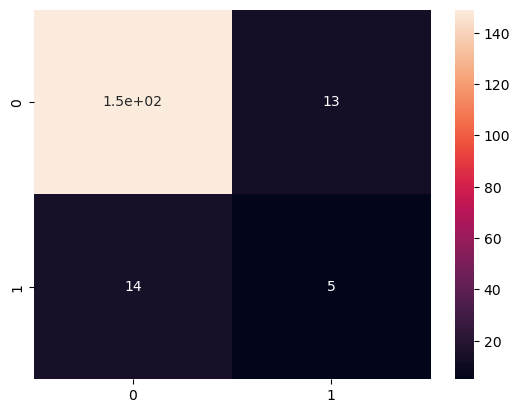

In [44]:
sns.heatmap(confusion_matrix(y_test, btahmin), annot=True) #BernoulliNB modelinin hata/doğru dağılımını grafik olarak gösterir

In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
L = LogisticRegression()

In [47]:
L.fit(x_train, y_train)

LogisticRegression()

In [48]:
ltahmin = L.predict(x_test)

In [49]:
accuracy_score(y_test, ltahmin)

0.9005524861878453

In [50]:
confusion_matrix(y_test, ltahmin)

array([[162,   0],
       [ 18,   1]])

In [51]:
# Karar Ağaçları

In [52]:
from sklearn.tree import DecisionTreeClassifier

In [53]:
d = DecisionTreeClassifier()

In [54]:
d.fit(x_train, y_train)

DecisionTreeClassifier()

In [55]:
dtahmin = d.predict(x_test)

In [56]:
accuracy_score(y_test, dtahmin)

0.7900552486187845

In [57]:
confusion_matrix(y_test, dtahmin)

array([[137,  25],
       [ 13,   6]])

### Bütün modelleri eğiten kod kümesi

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb= GradientBoostingClassifier()
kn= KNeighborsClassifier()
ab= AdaBoostClassifier()
mn= MultinomialNB()

def algo_test(x, y):
    modeller=[ b, l, d, r, gb, kn, ab, mn]
    isimler=["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
             "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
             "AdaBoostClassifier", "MultinomialNB"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state = 42)
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl=[]

    print("Veriler hazır modeller deneniyor")
    for model in modeller:
        print(model, " modeli eğitiliyor!..")
        model=model.fit(x_train,y_train)
        tahmin=model.predict(x_test)
        mdl.append(model)
        accuracy.append(accuracy_score(y_test, tahmin))
        precision.append(precision_score(y_test, tahmin, average="micro"))
        recall.append(recall_score(y_test, tahmin, average="micro"))
        f1.append(f1_score(y_test, tahmin, average="micro"))
        print(confusion_matrix(y_test, tahmin))

    print("Eğitim tamamlandı.")
    
    metrics=pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=isimler)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"]=mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("En başarılı model: ", metrics.iloc[0].name)
    model=metrics.iloc[0,-1]
    tahmin=model.predict(np.array(x_test) if model==kn else x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("classification Report:")
    print(classification_report(y_test, tahmin))
    print("Diğer Modeller:")
    
    return metrics.drop("Model", axis=1)

In [59]:
algo_test(x,y)

Veriler hazır modeller deneniyor
BernoulliNB()  modeli eğitiliyor!..
[[192  19]
 [ 23   7]]
LogisticRegression()  modeli eğitiliyor!..
[[209   2]
 [ 30   0]]
DecisionTreeClassifier()  modeli eğitiliyor!..
[[173  38]
 [ 21   9]]
RandomForestClassifier()  modeli eğitiliyor!..
[[211   0]
 [ 28   2]]
GradientBoostingClassifier()  modeli eğitiliyor!..
[[208   3]
 [ 24   6]]
KNeighborsClassifier()  modeli eğitiliyor!..
[[205   6]
 [ 29   1]]
AdaBoostClassifier()  modeli eğitiliyor!..
[[204   7]
 [ 21   9]]
MultinomialNB()  modeli eğitiliyor!..
[[115  96]
 [  9  21]]
Eğitim tamamlandı.
En başarılı model:  GradientBoostingClassifier
Confusion Matrix:
[[208   3]
 [ 24   6]]
classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       211
           1       0.67      0.20      0.31        30

    accuracy                           0.89       241
   macro avg       0.78      0.59      0.62       241
weighted avg       0.87      0.

,Accuracy,Precision,Recall,F1
GradientBoostingClassifier,0.887967,0.887967,0.887967,0.887967
RandomForestClassifier,0.883817,0.883817,0.883817,0.883817
AdaBoostClassifier,0.883817,0.883817,0.883817,0.883817
LogisticRegression,0.867220,0.867220,0.867220,0.867220
KNeighborsClassifier,0.854772,0.854772,0.854772,0.854772
BernoulliNB,0.825726,0.825726,0.825726,0.825726
DecisionTreeClassifier,0.755187,0.755187,0.755187,0.755187
MultinomialNB,0.564315,0.564315,0.564315,0.564315


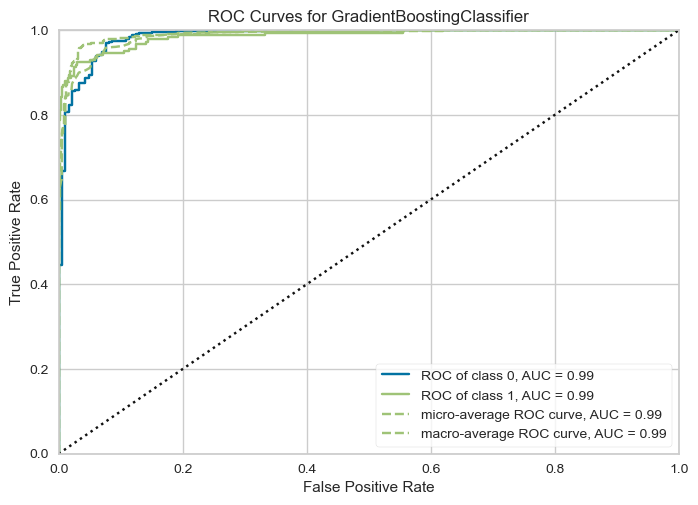

In [60]:
from yellowbrick.classifier import roc_auc
from yellowbrick.datasets import load_spam
from sklearn.linear_model import LogisticRegression
visualizer = roc_auc(GradientBoostingClassifier(), x, y)

Bu projede kimlerin işten ayrılacağını tahmin eden bir model geliştirdik.
Başarı oranımız %90 çıktı